In [ ]:
"""Linear regression by using Deep Neural network: Implement Boston housing
price.prediction problem by Linear regression using Deep Neural network. Use Boston House price
prediction dataset."""

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Boston Dataset (updated method)
from sklearn.datasets import fetch_openml

In [3]:
housing = fetch_openml(name="boston", version=1, as_frame=True)
X = housing.data
y = housing.target.astype(float)

In [4]:
# Combine into DataFrame
data = X.copy()
data['PRICE'] = y

In [5]:
# Basic info
print(data.head())
print(data.shape)
print(data.isnull().sum())

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  PRICE  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  
(506, 14)
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64


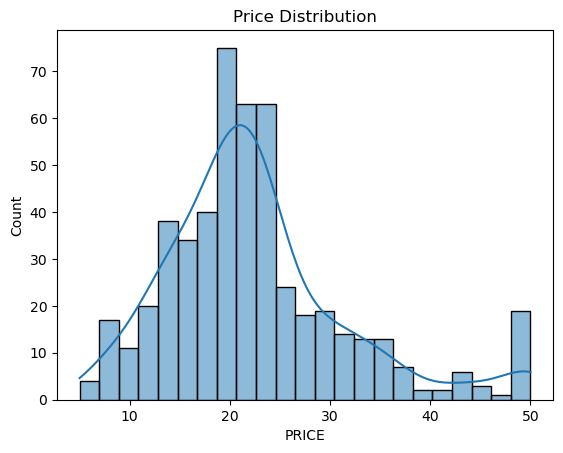

In [6]:
# Visualization
sns.histplot(data['PRICE'], kde=True)
plt.title("Price Distribution")
plt.show()

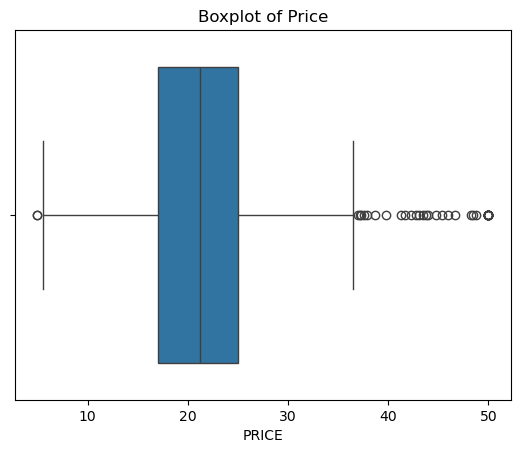

In [7]:
sns.boxplot(x=data['PRICE'])
plt.title("Boxplot of Price")
plt.show()

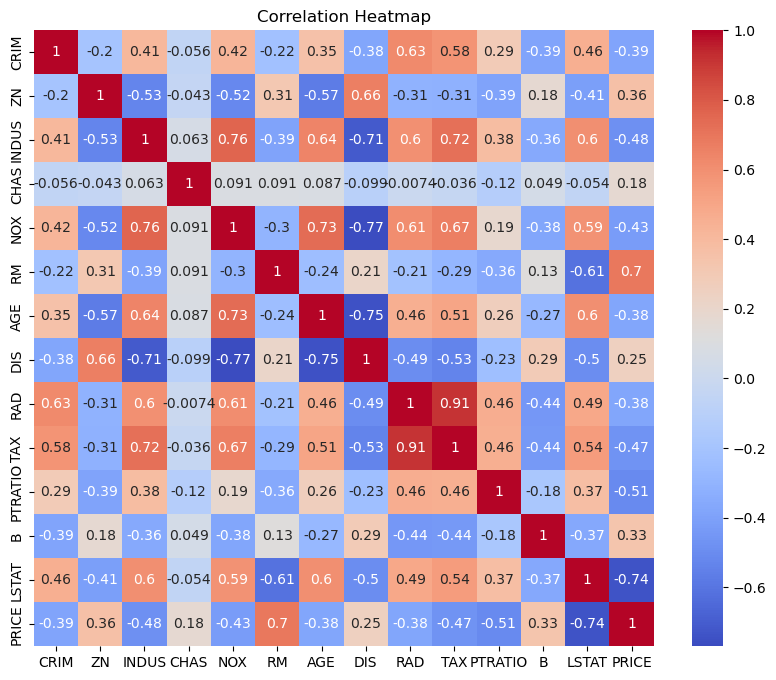

In [8]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [9]:
# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# -------------------------------
# 1. Linear Regression Model
# -------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("\n--- Linear Regression ---")
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("R2 Score:", r2_score(y_test, y_pred_lr))


--- Linear Regression ---
RMSE: 4.928602182665338
MAE: 3.1890919658878483
R2 Score: 0.6687594935356318


In [12]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [13]:
# -------------------------------
# 2. Deep Neural Network Model
# -------------------------------

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

C:\Users\praga\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 581.0474 - mae: 22.1341 - val_loss: 536.0933 - val_mae: 21.5195
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 505.6689 - mae: 20.2930 - val_loss: 437.3358 - val_mae: 19.0482
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 379.7339 - mae: 16.9407 - val_loss: 270.6934 - val_mae: 14.3154
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 197.0317 - mae: 11.5528 - val_loss: 94.1823 - val_mae: 7.3569
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 82.3705 - mae: 7.0896 - val_loss: 49.5043 - val_mae: 4.7957
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 52.2336 - mae: 5.6169 - val_loss: 38.4340 - val_mae: 3.9730
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 34.3248 - mae: 4.2879 - val_loss: 40.8929 - val_mae: 4.2111
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 28.2223 - mae: 3.8350 - val_loss: 37.6852 - val_mae: 4.1569
Epoch 9/100
12/12 ━━━━━━━━━━━

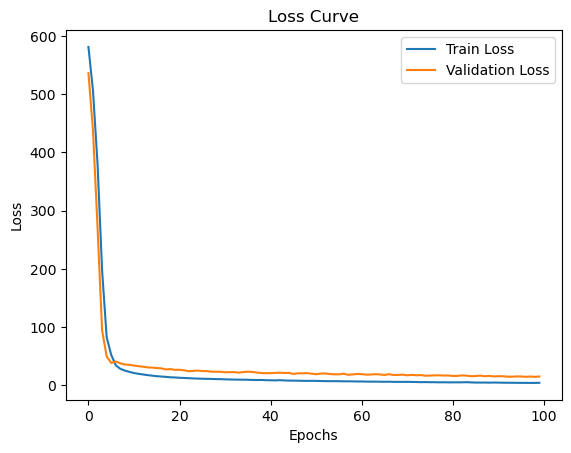

In [15]:
# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

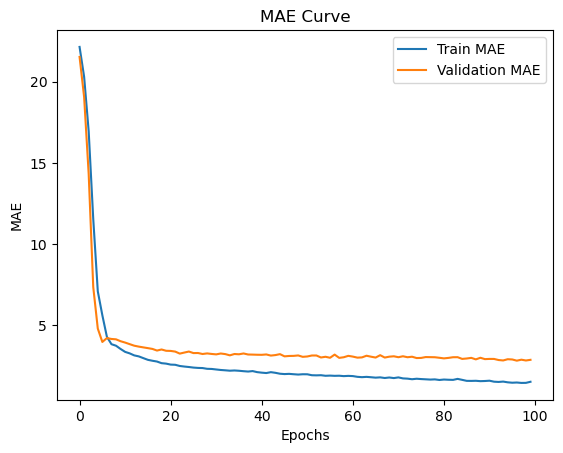

In [16]:
# Plot MAE
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title("MAE Curve")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

In [17]:
# Evaluate model
mse_nn, mae_nn = model.evaluate(X_test, y_test)

print("\n--- Deep Neural Network ---")
print("MSE:", mse_nn)
print("MAE:", mae_nn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11.4103 - mae: 2.1626

--- Deep Neural Network ---
MSE: 11.410284042358398
MAE: 2.1625983715057373


In [18]:
# Compare models
print("\n--- Comparison ---")
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))
print("Neural Network MAE:", mae_nn)


--- Comparison ---
Linear Regression MAE: 3.1890919658878483
Neural Network MAE: 2.1625983715057373


In [19]:
# Prediction on new data
new_data = np.array([X.iloc[0]])  # Example input
new_data = scaler.transform(new_data)

prediction = model.predict(new_data)
print("\nPredicted Price:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step

Predicted Price: [[23.915995]]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
